# Lecture 7 — Matrix Factorization and Collaborative Filtering

This notebook develops the lecture's matrix-factorization idea from the ground up.

- **$Y$** is the observed ratings matrix. Many entries are missing.
- **$X$** is the unknown complete ratings matrix.
- **$\hat X$** is the model's reconstructed/predicted complete matrix.
- **$U,V$** are learned latent-factor matrices.


## 1. The lecture example

$$Y=\begin{bmatrix}5&?&7\\1&2&?\end{bmatrix}$$

The lecture initializes $v=(2,7,8)^T$. The values $2,7,8$ are **latent movie-factor values**, not ratings copied from $Y$. Thus user 1 uses $(5-2u_1)^2$ and $(7-8u_1)^2$; the observed rating `1` is used for user 2.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)
Y=np.array([[5.,np.nan,7.],[1.,2.,np.nan]])
v=np.array([2.,7.,8.])
print('Y =\n',Y)
print('v =',v)


Y =
 [[ 5. nan  7.]
 [ 1.  2. nan]]
v = [2. 7. 8.]


## 2. Rank-1 reconstruction

$$uv^T=\begin{bmatrix}u_1v_1&u_1v_2&u_1v_3\\u_2v_1&u_2v_2&u_2v_3\end{bmatrix}$$

One prediction is $\hat X_{ai}=u_av_i$. The factors are latent representations, not ratings themselves.


In [2]:
u_demo=np.array([1.,2.])
print(np.outer(u_demo,v))


[[ 2.  7.  8.]
 [ 4. 14. 16.]]


## 3. Observed entries and objective

Let $\Omega=\{(a,i):Y_{ai}\text{ is observed}\}$. For rank 1:

$$J(u,v)=\frac12\sum_{(a,i)\in\Omega}(Y_{ai}-u_av_i)^2+\frac{\lambda}{2}\left(\sum_a u_a^2+\sum_i v_i^2\right).$$

Missing entries are not included because their true ratings are unknown.


In [3]:
def objective_rank1(Y,u,v,lam):
    mask=~np.isnan(Y); r=Y[mask]-np.outer(u,v)[mask]
    return .5*np.sum(r*r)+.5*lam*(np.sum(u*u)+np.sum(v*v))


## 4. Alternating minimization

With $v$ fixed:

$$u_a=\frac{\sum_{i:(a,i)\in\Omega}Y_{ai}v_i}{\lambda+\sum_{i:(a,i)\in\Omega}v_i^2}.$$

For $v=(2,7,8)$ and $\lambda=1$:

$$u_1=\frac{5(2)+7(8)}{1+2^2+8^2}=\frac{66}{69},\qquad u_2=\frac{1(2)+2(7)}{1+2^2+7^2}=\frac{16}{54}.$$

With $u$ fixed:

$$v_i=\frac{\sum_{a:(a,i)\in\Omega}Y_{ai}u_a}{\lambda+\sum_{a:(a,i)\in\Omega}u_a^2}.$$

We alternate $v\rightarrow u\rightarrow v$. The joint problem is non-convex, so initialization can affect the local solution.


In [4]:
def update_u(Y,v,lam):
    u=np.zeros(Y.shape[0])
    for a in range(Y.shape[0]):
        mask=~np.isnan(Y[a]); u[a]=np.sum(Y[a,mask]*v[mask])/(lam+np.sum(v[mask]**2))
    return u

def update_v(Y,u,lam):
    v=np.zeros(Y.shape[1])
    for i in range(Y.shape[1]):
        mask=~np.isnan(Y[:,i]); v[i]=np.sum(Y[mask,i]*u[mask])/(lam+np.sum(u[mask]**2))
    return v

def factor_rank1(Y,lam=1.,v_init=None,max_iter=500,tol=1e-8):
    rng=np.random.default_rng(0); v=rng.normal(size=Y.shape[1]) if v_init is None else np.array(v_init,dtype=float); history=[]
    for _ in range(max_iter):
        u=update_u(Y,v,lam); v=update_v(Y,u,lam); history.append(objective_rank1(Y,u,v,lam))
        if len(history)>1 and abs(history[-1]-history[-2])<tol: break
    return u,v,np.array(history)

u_fit,v_fit,history=factor_rank1(Y,v_init=[2,7,8]); Xhat=np.outer(u_fit,v_fit)
print('u =',u_fit); print('v =',v_fit); print('Xhat =\n',Xhat)


u = [2.782 0.798]
v = [1.569 0.975 2.228]
Xhat =
 [[4.364 2.712 6.199]
 [1.251 0.778 1.777]]


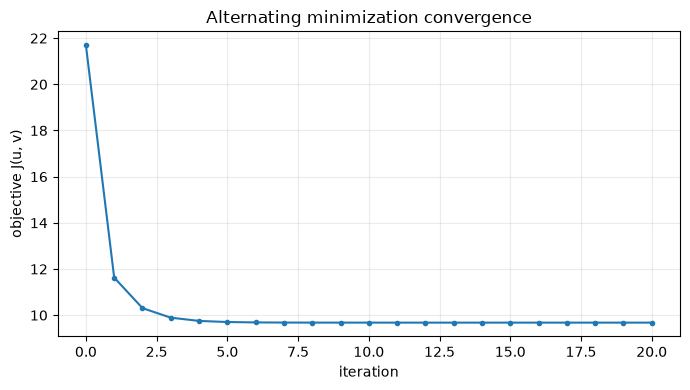

In [5]:
plt.figure(figsize=(7,4)); plt.plot(history,marker='o',markersize=3)
plt.xlabel('iteration'); plt.ylabel('objective J(u, v)'); plt.title('Alternating minimization convergence')
plt.grid(True,alpha=.25); plt.tight_layout(); plt.show()


## 5. Rank $k$

$$U\in\mathbb{R}^{n\times k},\qquad V\in\mathbb{R}^{m\times k},\qquad \hat X=UV^T.$$

One predicted rating is the inner product:

$$\hat X_{ai}=u_a^Tv_i=\sum_{r=1}^{k}U_{ar}V_{ir}.$$

Thus $u_a^Tv_i$ gives one prediction, while $UV^T$ gives all predictions. **$k$ is the number of latent dimensions, not a rating and not a deduced rating.**

$$J(U,V)=\frac12\sum_{(a,i)\in\Omega}(Y_{ai}-u_a^Tv_i)^2+\frac{\lambda}{2}(\|U\|_F^2+\|V\|_F^2).$$


In [6]:
def objective_rank_k(Y,U,V,lam):
    mask=~np.isnan(Y); r=Y[mask]-(U@V.T)[mask]
    return .5*np.sum(r*r)+.5*lam*(np.sum(U*U)+np.sum(V*V))

def factor_rank_k(Y,k,lam=.1,max_iter=500,tol=1e-8,seed=0):
    rng=np.random.default_rng(seed); n,m=Y.shape; U=.1*rng.normal(size=(n,k)); V=.1*rng.normal(size=(m,k)); I=np.eye(k); history=[]
    for _ in range(max_iter):
        for a in range(n):
            mask=~np.isnan(Y[a]); A=V[mask].T@V[mask]+lam*I; b=V[mask].T@Y[a,mask]; U[a]=np.linalg.solve(A,b)
        for i in range(m):
            mask=~np.isnan(Y[:,i]); A=U[mask].T@U[mask]+lam*I; b=U[mask].T@Y[mask,i]; V[i]=np.linalg.solve(A,b)
        history.append(objective_rank_k(Y,U,V,lam))
        if len(history)>1 and abs(history[-1]-history[-2])<tol: break
    return U,V,np.array(history)


## 6. Synthetic matrix completion

We generate a true low-rank matrix, hide entries, fit only observed entries, and compare with the truth. The complete truth is known only because this is synthetic.


In [7]:
rng=np.random.default_rng(42); n_users,n_movies,k_true=8,7,2
U_true=rng.normal(size=(n_users,k_true)); V_true=rng.normal(size=(n_movies,k_true)); X_true=U_true@V_true.T
mask=rng.random((n_users,n_movies))<.55; Y_synth=np.where(mask,X_true,np.nan)
U_hat,V_hat,h=factor_rank_k(Y_synth,2,lam=.05,seed=1); Xhat_k=U_hat@V_hat.T
obs_rmse=np.sqrt(np.mean((Xhat_k[mask]-X_true[mask])**2)); miss_rmse=np.sqrt(np.mean((Xhat_k[~mask]-X_true[~mask])**2))
print('Observed RMSE:',obs_rmse); print('Missing RMSE:',miss_rmse)


Observed RMSE: 0.02628408954391988
Missing RMSE: 0.1923946004312203


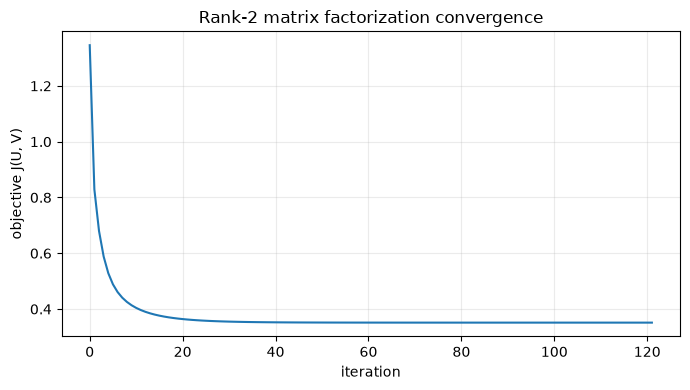

In [8]:
plt.figure(figsize=(7,4)); plt.plot(h); plt.xlabel('iteration'); plt.ylabel('objective J(U, V)'); plt.title('Rank-2 matrix factorization convergence'); plt.grid(True,alpha=.25); plt.tight_layout(); plt.show()


## 7. Initialization, parameter count, and choosing $k$

A rank-$k$ model uses $k(n+m)$ latent parameters instead of $nm$. Initialization affects which local solution optimization reaches; multiple restarts can help. This is different from $k$, which is a hyperparameter.

A validation workflow trains candidate values of $k$, scores them on validation data, selects the best one, retrains, and evaluates once on the untouched test set. If larger score is better:

$$k^*=\arg\max_k S_{\mathrm{val}}(k).$$


## 8. Final conceptual picture

| Object | Meaning |
|---|---|
| $Y$ | observed ratings with missing entries |
| $X$ | unknown real complete ratings matrix |
| $U,V$ | learned latent-factor matrices |
| $\hat X$ | predicted/reconstructed complete matrix |
| $k$ | number of latent dimensions |
| $\lambda$ | regularization strength |
| $\Omega$ | observed user-movie pairs |

$$\boxed{\hat X=UV^T}$$

$$\boxed{\hat X_{ai}=u_a^Tv_i}$$

Observed ratings provide the evidence; latent factors are learned; the complete prediction matrix is reconstructed; missing ratings are predicted.
